# Run correlations for SVI before and after fixing errors
Compare correlations between CDC, HRRC, and UT before and after found errors and table adjustments.

## Description of Program
- program:    tu3svi4_6bv2_Table2
- task:       Set up table for published paper
- Version:    2024-04-29
- 2024-06-13: Update HRRC with fixed Group Quarters data
- 2024-06-13: Add check for differences in SVI percentile and quartiles
- 2025-04-12: Update with 2020 SVI and only look at 1 versions
- 2025-04-16: Updated UTP to SVInsight for figures
- project:    DOE Southeast Texas Urban Field Lab SVI Paper - round 4 of analysis 
- funding:	  DOE
- author:    Nathanael Rosenheim
- GRA:        Lidia Mezei

## Control Python
Add install and add packages.

In [1]:
import pandas as pd     # For obtaining and cleaning tabular data
import geopandas as gpd # For obtaining and cleaning spatial data
import numpy as np      # For working with arrays
import geopandas as gpd # For working with spatial data
import matplotlib.pyplot as plt # For plotting
import os # For saving to path

In [2]:
import sys
print("Python Version     ", sys.version)
print("geopandas version: ", gpd.__version__)

Python Version      3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50) [MSC v.1916 64 bit (AMD64)]
geopandas version:  0.14.2


## Set Provenance 

In [3]:
# Get information on current working directory (getcwd)
os.getcwd()

'c:\\Users\\nathanael99\\Box\\SETx-UIFL_Team-folder\\Theme_3_eq\\Text\\SVI_Analysis_Paper\\WorkNPR'

In [ ]:
# Store Program Name for oSVInsightut files to have the same name and saved in the same directory
programname = "tu3svi4_6bv2_Table2_2025-04-16"
# Make directory to save output
if not os.path.exists(programname):
   os.mkdir(programname)

# Obtain Data
Obtain data from about each variable in SVI data.

In [5]:
# read in original Version 1 data
sourceprogram = "tu3svi4_2av2_SVIoptions_2025-04-12"
sourcefile = sourceprogram+"/"+sourceprogram+"_all_vars_tract2020.csv"
# read in file and set ids as strings
Tract_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str})

sourcefile = sourceprogram+"/"+sourceprogram+"_all_vars_bg2020.csv"
BG_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str, 'BG2020': str})

C:\Users\nathanael99\AppData\Local\Temp\ipykernel_6204\2666266851.py:8: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  BG_df = pd.read_csv(sourcefile, dtype={'TRACT2020':str, 'BG2020': str})


In [6]:
Tract_df.head()

,TRACT2020,U202020010,U202020013,U202020020,U202020031,U202020033,U202020040,U202020070,U202021010,U202030020,...,H202081011,H202090012,H202090093,H202091012,H202091093,H202092021,SETX,FIPSCNTY,airsite_tract,airsite_name
0,48001950100,0.17643,0.39966,0.08209,-28193.0,-0.03541,-110400.0,850.0,0.08734,0.75434,...,0.22428,62.3,0.569,3.0,3.0,1.0,0,48001,0,NaN
1,48001950401,0.00000,0.08642,0.00000,-2399.0,-0.00000,-9999.0,198.0,0.26896,0.05774,...,0.17284,15.3,0.293,1.0,1.0,1.0,0,48001,0,NaN
2,48001950402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00000,1.1,0.078,1.0,1.0,1.0,0,48001,0,NaN
3,48001950500,0.15177,0.41750,0.04048,-17849.0,-0.00933,-85400.0,712.0,0.14249,0.75733,...,0.23745,81.6,0.692,4.0,4.0,1.0,0,48001,0,NaN
4,48001950600,0.19861,0.48890,0.03490,-23062.0,-0.00986,-97100.0,888.0,0.27191,0.75914,...,0.28175,84.9,0.717,4.0,4.0,1.0,0,48001,0,NaN


In [7]:
# read in table 1 details
sourceprogram = "tu3svi4_6av1_Table1_2025-04-12"
sourcefile = sourceprogram+"/"+sourceprogram+".csv"
table1_df = pd.read_csv(sourcefile)
table1_df.head()

,year,General Category,gencatcode,comcatcode,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname UTP
0,2018,Geocode,100,10,TRACT2010,NaN,NaN,NaN,C201810010,H201810010,U201810010
1,2020,Geocode,100,10,TRACT2020,NaN,NaN,NaN,C202010010,H202010010,U202010010
2,2018,Geocode,100,11,BG2010,NaN,NaN,NaN,NaN,H201810011,U201810011
3,2020,Geocode,100,11,BG2020,NaN,NaN,NaN,NaN,H202010011,U202010011
4,2018,Denominator,100,20,Population,S0601,unknown,NaN,C201810020,H201810020,NaN


In [8]:
# read in table 1 details - manually updated from Table 1
sourcefile= "tu3svi4_6av1_Table1_2025-04-12_variables_to_compare.csv"
corrvars_df = pd.read_csv(sourcefile)
corrvars_df.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname UTP
0,2020,Denominator,Population,S0601,unknown,NaN,C202010020,H202010020,NaN
1,2020,Denominator,Households,DP02,unknown,NaN,C202010030,H202010030,NaN
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,NaN,B17017,NaN,NaN,H202020012,U202020013
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020


## Clean data

In [ ]:
# rename newvarname UTP = newvarname SVInsight
table1_df.rename(columns={'newvarname UTP': 'newvarname SVInsight'}, inplace=True)
table1_df.head()

,year,General Category,gencatcode,comcatcode,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight
0,2018,Geocode,100,10,TRACT2010,NaN,NaN,NaN,C201810010,H201810010,U201810010
1,2020,Geocode,100,10,TRACT2020,NaN,NaN,NaN,C202010010,H202010010,U202010010
2,2018,Geocode,100,11,BG2010,NaN,NaN,NaN,NaN,H201810011,U201810011
3,2020,Geocode,100,11,BG2020,NaN,NaN,NaN,NaN,H202010011,U202010011
4,2018,Denominator,100,20,Population,S0601,unknown,NaN,C201810020,H201810020,NaN


In [ ]:
# fill missing values with ''
corrvars_df.fillna('', inplace=True)
# rename newvarname UTP = newvarname SVInsight
corrvars_df.rename(columns={'newvarname UTP': 'newvarname SVInsight'}, inplace=True)

In [10]:
corrvars_df.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight
0,2020,Denominator,Population,S0601,unknown,,C202010020,H202010020,
1,2020,Denominator,Households,DP02,unknown,,C202010030,H202010030,
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,,B17017,,,H202020012,U202020013
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020


# Explore Results

### Correlations between key variabes

In [ ]:
# loop through correlation vars and add correlation
table2_df = corrvars_df.copy()
for index, row in table2_df.iterrows():
    common_category = row['Common Category']
    cdc_varname = row['newvarname CDC']
    hrrc_varname = row['newvarname HRRC']
    SVInsight_varname = row['newvarname SVInsight']

    print(common_category, cdc_varname, hrrc_varname, SVInsight_varname)
    # check if cdc and hrrc varnames are not missing
    if cdc_varname != '' and hrrc_varname != '':
        # get the correlation between the two variables
        corr = Tract_df[cdc_varname].corr(Tract_df[hrrc_varname])
        table2_df.loc[index, 'CDC-HRRC'] = corr
    # check if cdc and SVInsight varnames are not missing
    if cdc_varname != '' and SVInsight_varname != '':
        # get the correlation between the two variables
        corr = Tract_df[cdc_varname].corr(Tract_df[SVInsight_varname])
        table2_df.loc[index, 'CDC-SVInsight'] = corr
    # check if hrrc and SVInsight varnames are not missing
    if hrrc_varname != '' and SVInsight_varname != '':
        # get the correlation between the two variables
        corr = Tract_df[hrrc_varname].corr(Tract_df[SVInsight_varname])
        table2_df.loc[index, 'HRRC-SVInsight_tract'] = corr
        # get the correlation between the two variables
        corr = BG_df[hrrc_varname].corr(BG_df[SVInsight_varname])
        table2_df.loc[index, 'HRRC-SVInsight_BG'] = corr

Population C202010020 H202010020 
Households C202010030 H202010030 
Poverty C202020010 H202020010 U202020010
Elder Households in Poverty (HRRC) vs Households with Social Security Income (SVInsight)  H202020012 U202020013
Unemployed C202020020 H202020020 U202020020
Housing Cost Burden (CDC) vs Per Capita Income Past 12 Months (SVInsight) C202020031  U202020031
No Insurance C202020050  U202020050
No High School Diploma C202021010 H202021010 U202021010
Aged 65 or Older (CDC) vs Elder Households (HRRC) vs Population Under 5 and Over 65 (SVInsight) C202030010 H202030011 U202030020
Single-parent C202033010 H202033010 U202033010
Aged 17 or Younger (CDC) vs Children Under 5 Years Population (HRRC) C202033020 H202033025 
Minority C202060010 H202060010 
Native American, not Hispanic (SVInsight) vs Minority C202060010 H202060010 U202060021
African American, not Hispanic (SVInsight) vs Minority C202060010 H202060010 U202060022
Asian, not Hispanic (SVInsight) vs Minority C202060010 H202060010 U2020

In [13]:
table2_df.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight,CDC-HRRC,CDC-SVInsight,HRRC-SVInsight_tract,HRRC-SVInsight_BG
0,2020,Denominator,Population,S0601,unknown,,C202010020,H202010020,,1.000000,NaN,NaN,NaN
1,2020,Denominator,Households,DP02,unknown,,C202010030,H202010030,,1.000000,NaN,NaN,NaN
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010,0.904353,0.905222,1.000000,1.000000
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,,B17017,,,H202020012,U202020013,NaN,NaN,0.397902,0.322845
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020,0.995160,0.999979,0.994963,0.997444


In [14]:
table2_df_v2 = table2_df.copy(deep=True)
# format columns
format_cols = ['CDC-HRRC', 'CDC-SVInsight', 'HRRC-SVInsight_tract', 'HRRC-SVInsight_BG']
table2_df_v2[format_cols] = table2_df_v2[format_cols].map("{:.2f}".format)
# convert to format string
table2_df_v2[format_cols] = table2_df_v2[format_cols].astype(str)
# replace 'nan' with ''
table2_df_v2[format_cols] = table2_df_v2[format_cols].replace('nan', '')
table2_df_v2.head()

,year,General Category,Common Category,CDC,HRRC,SVInsight,newvarname CDC,newvarname HRRC,newvarname SVInsight,CDC-HRRC,CDC-SVInsight,HRRC-SVInsight_tract,HRRC-SVInsight_BG
0,2020,Denominator,Population,S0601,unknown,,C202010020,H202010020,,1.00,,,
1,2020,Denominator,Households,DP02,unknown,,C202010030,H202010030,,1.00,,,
2,2020,Economic,Poverty,S1701,B17021,B17021,C202020010,H202020010,U202020010,0.90,0.91,1.00,1.00
3,2020,Economic,Elder Households in Poverty (HRRC) vs Househol...,,B17017,,,H202020012,U202020013,,,0.40,0.32
4,2020,Economic,Unemployed,DP03,B23025,B23025,C202020020,H202020020,U202020020,1.00,1.00,0.99,1.00


In [15]:
# Save output as csv
table2_df_v2.to_csv(programname+"/"+programname+".csv", index=False)


### Explore with Scatter plots

In [ ]:
# Scatter plots for Single Parent Households
# look up variables for Single Parent Households
common_category = 'Single-parent'
condition = table2_df_v2['Common Category'] == common_category
cdc_varname = table2_df_v2.loc[condition, 'newvarname CDC'].values[0]
hrrc_varname = table2_df_v2.loc[condition, 'newvarname HRRC'].values[0]
SVInsight_varname = table2_df_v2.loc[condition, 'newvarname SVInsight'].values[0]
cat_vars_tract = [cdc_varname, hrrc_varname, SVInsight_varname]
cat_vars_bg = [hrrc_varname, SVInsight_varname]
print(common_category, cat_vars_tract)

Single-parent ['C202033010', 'H202033010', 'U202033010']


In [17]:
# select southeast texas counties
svi_tract_gdf_setx = Tract_df[Tract_df['SETX'] == 1].copy(deep=True)
# convert to percentage
for var in cat_vars_tract:
    svi_tract_gdf_setx[var] = svi_tract_gdf_setx[var] * 100
svi_tract_gdf_airsite = svi_tract_gdf_setx[svi_tract_gdf_setx['airsite_tract'] == 1].copy(deep=True)
svi_tract_gdf_airsite[['TRACT2020','H202010020','H202010030']+cat_vars_tract+['C202090012','H202090012','U202090012','airsite_name']].head(10)


,TRACT2020,H202010020,H202010030,C202033010,H202033010,U202033010,C202090012,H202090012,U202090012,airsite_name
4439,48245005100,1079.0,448.0,6.0,13.839,89.855,44.16,51.0,71.062,W1
4443,48245005900,1459.0,601.0,33.4,36.106,87.500,75.61,83.5,37.670,W2
4448,48245006600,3908.0,1597.0,20.6,21.603,53.241,96.46,91.9,82.799,E1
4461,48245010600,5633.0,1968.0,4.1,8.587,22.869,55.81,38.2,63.912,E2


In [18]:

# select southeast texas counties
svi_bg_gdf_setx = BG_df[BG_df['SETX'] == 1].copy(deep=True)
# covert cat_vars_bg to percentage
for var in cat_vars_bg:
    svi_bg_gdf_setx[var] = svi_bg_gdf_setx[var] * 100
svi_bg_gdf_airsite = svi_bg_gdf_setx[svi_bg_gdf_setx['airsite_bg'] == 1].copy(deep=True)
svi_bg_gdf_airsite[['BG2020','H202010020','H202010030']+cat_vars_bg+['H202090012','U202090012','airsite_name']].head(10)

,BG2020,H202010020,H202010030,H202033010,U202033010,H202090012,U202090012,airsite_name
11974,482450051001,572,247,14.170,100.000,69.2,77.289,W1.1
11975,482450051002,507,201,13.433,79.412,44.5,62.124,W1.2
11986,482450059001,1110,439,33.257,82.486,85.9,50.179,W2.1
11987,482450059002,349,162,43.827,100.000,89.3,86.698,W2.2
11999,482450066001,149,96,0.000,NaN,31.7,95.184,E1.1
12038,482450106005,947,327,20.183,61.111,45.5,48.360,E2.1


In [ ]:
def select_svi_vars(df, cat_vars, airsite_var):
    # select southeast texas counties
    df_setx = df[df['SETX'] == 1].copy(deep=True)
    # convert to percentage
    for var in cat_vars:
        df_setx[var] = df_setx[var] * 100
    df_airsites = df_setx[df_setx[airsite_var] == 1].copy(deep=True)

    return df_setx, df_airsites

def axes_plot(num = 0, 
              axes = None,
              df = svi_tract_gdf_setx, 
              site_df = svi_tract_gdf_airsite, 
              svi1 = 'C202090012', 
              svi2 = 'H202090012', 
              title = 'CDC vs HRRC Census Tract', 
              label1 = 'CDC', 
              label2 = 'HRRC',
              legend1 = 'Tract',
              legend2 = 'Air Site Tract') -> plt.Axes:
    
    # check if missing values
    if site_df[svi1].isnull().any():
        print(f"Missing values in {svi1} for air site tract")
        length = len(site_df[svi1])
        # drop missing values
        site_df = site_df.dropna(subset=[svi1])
        length2 = len(site_df[svi1])
        print(f"Missing values in {svi1} dropped {length - length2} rows")
    if site_df[svi2].isnull().any():
        print(f"Missing values in {svi2} for air site tract")
        length = len(site_df[svi2])
        # drop missing values
        site_df = site_df.dropna(subset=[svi2])
        length2 = len(site_df[svi2])
        print(f"Missing values in {svi2} dropped {length - length2} rows")


    ax = axes[num]

    # fix the min and max values for the axes to 1
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)

    # Scatter plot for all of study area
    ax.scatter(df[svi1], df[svi2], alpha=1, marker='+', color='#b2abd2', label =legend1)
    ax.scatter(site_df[svi1], site_df[svi2], 
                    alpha=1,
                    color='#e66101',
                    edgecolor='black',
                    linewidth=0.5,
                    s=100,
                    label = legend2) # increase size of points
    # use airsite name to label points
    for i, row in site_df.iterrows():
        ax.text(row[svi1]-3, row[svi2], row['airsite_name'], fontsize=12, ha='right', weight='bold')
    ax.set_xlabel(label1)
    ax.set_ylabel(label2)
    ax.set_title(title)

    ax.legend(loc='lower right', fontsize=10)
    return ax


def generate_plot(svi_tract_gdf_setx,
                    svi_tract_gdf_airsite, 
                    svi_bg_gdf_setx, 
                    svi_bg_gdf_airsite,
                    commonlabel,
                    cdc_varname, 
                    hrrc_varname, 
                    SVInsight_varname, 
                    label_cdc,
                    label_hrrc,
                    label_SVInsight):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes_plot(0, axes=axes, 
                df = svi_tract_gdf_setx, 
                site_df = svi_tract_gdf_airsite, 
                svi1=cdc_varname, svi2=hrrc_varname, 
                label1=label_cdc, label2=label_hrrc, 
                title='CDC vs HRRC Census Tract', 
                legend1='Tract',
                legend2='Air Site Tract')
    axes_plot(1, axes=axes, 
                df = svi_tract_gdf_setx, 
                site_df = svi_tract_gdf_airsite, 
                svi1=cdc_varname, svi2=SVInsight_varname, 
                label1=label_cdc, label2=label_SVInsight, 
                title='CDC vs SVInsight Census Tract', 
                legend1='Tract',
                legend2='Air Site Tract')
    axes_plot(2, axes=axes, 
                df = svi_tract_gdf_setx, 
                site_df = svi_tract_gdf_airsite, 
                svi1=hrrc_varname, svi2=SVInsight_varname, 
                label1=label_hrrc, label2=label_SVInsight,
                title='HRRC vs SVInsight Census Tract', 
                legend1='Tract',
                legend2='Air Site Tract')
    axes_plot(3, axes=axes, 
                df = svi_bg_gdf_setx, 
                site_df = svi_bg_gdf_airsite, 
                svi1=hrrc_varname, svi2=SVInsight_varname,
                label1=label_hrrc, label2=label_SVInsight, 
                title='HRRC vs SVInsight Census Block Group', 
                legend1='Block Group',
                legend2='Air Site Block Group')


    # save figure
    outputfile = os.path.join(programname, f'{programname}_{commonlabel}.jpeg')
    plt.savefig(outputfile, dpi=600, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

In [ ]:
# Scatter plots for Age
common_category = 'Single-parent'
condition1 = table2_df_v2['Common Category'] == common_category

labels = {}
varnames = {}
cat_vars_tract = []

for svi_option in ['CDC', 'HRRC', 'SVInsight']:
    varnames[svi_option] = table2_df_v2.loc[condition1, f'newvarname {svi_option}'].values[0]
    condition2 = table1_df[f'newvarname {svi_option}'] == varnames[svi_option]
    labels[svi_option] = svi_option + ' ' + table1_df.loc[condition2, 'Common Category'].values[0]
    print(labels[svi_option])

cat_vars_tract = [varnames['CDC'], varnames['HRRC'], varnames['SVInsight']]
cat_vars_bg = [varnames['HRRC'], varnames['SVInsight']]
print(common_category, cat_vars_tract)

CDC Single-parent
HRRC Single-parent
UTP Single-parent
Single-parent ['C202033010', 'H202033010', 'U202033010']


Missing values in U202033010 for air site tract
Missing values in U202033010 dropped 1 rows


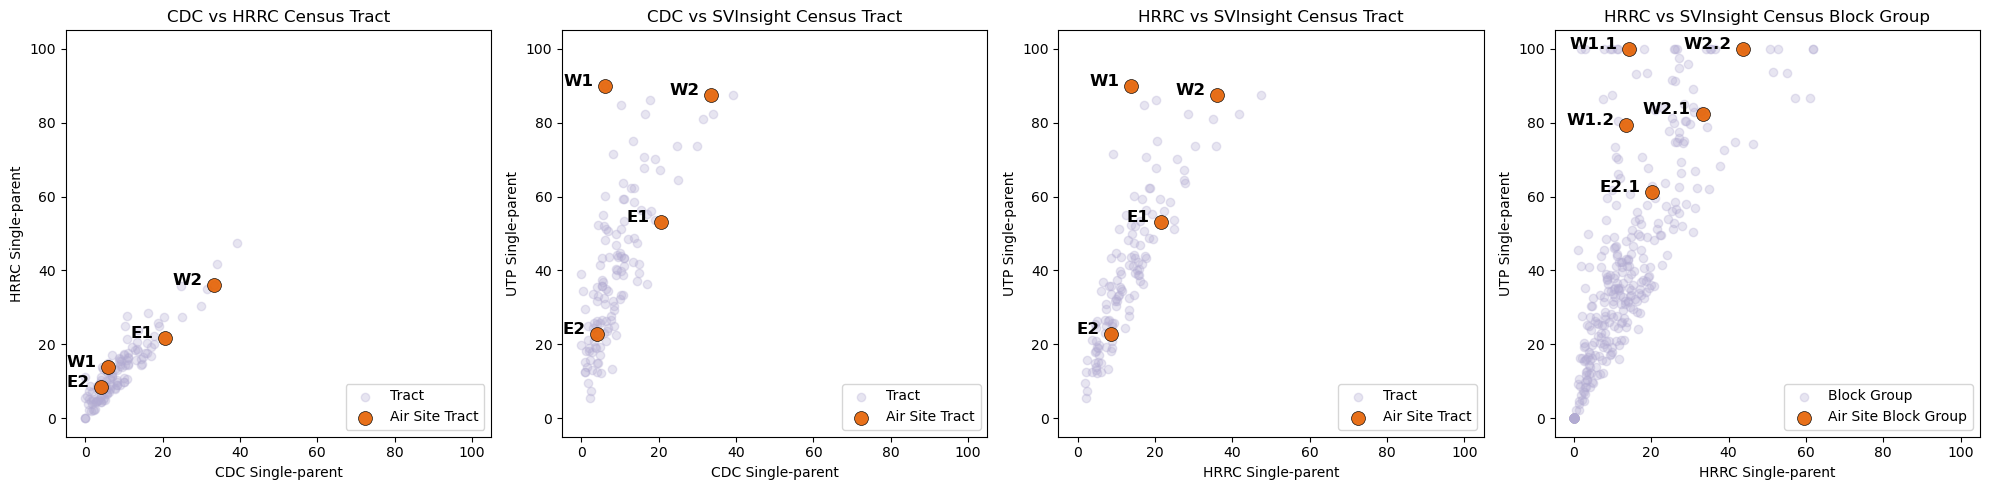

In [ ]:
svi_tract_gdf_setx, svi_tract_gdf_airsite = select_svi_vars(Tract_df, cat_vars_tract, airsite_var='airsite_tract')
svi_bg_gdf_setx, svi_bg_gdf_airsite = select_svi_vars(BG_df, cat_vars_bg, airsite_var='airsite_bg')
generate_plot(svi_tract_gdf_setx, 
              svi_tract_gdf_airsite, 
              svi_bg_gdf_setx, 
              svi_bg_gdf_airsite, 
              commonlabel = "single_parent",
              cdc_varname = varnames['CDC'],
              hrrc_varname = varnames['HRRC'],
              SVInsight_varname = varnames['SVInsight'],
              label_cdc = labels['CDC'],
              label_hrrc = labels['HRRC'],
              label_SVInsight = labels['SVInsight'])

In [ ]:
# Scatter plots for Age
common_category = 'Age'
condition1 = table2_df_v2['General Category'] == common_category

labels = {}
varnames = {}
cat_vars_tract = []

for svi_option in ['CDC', 'HRRC', 'SVInsight']:
    varnames[svi_option] = table2_df_v2.loc[condition1, f'newvarname {svi_option}'].values[0]
    condition2 = table1_df[f'newvarname {svi_option}'] == varnames[svi_option]
    labels[svi_option] = svi_option + ' ' + table1_df.loc[condition2, 'Common Category'].values[0]
    print(labels[svi_option])

cat_vars_tract = [varnames['CDC'], varnames['HRRC'], varnames['SVInsight']]
cat_vars_bg = [varnames['HRRC'], varnames['SVInsight']]
print(common_category, cat_vars_tract)


CDC Aged 65 or Older
HRRC Elder Households
UTP Population Under 5 and Over 65
Age ['C202030010', 'H202030011', 'U202030020']


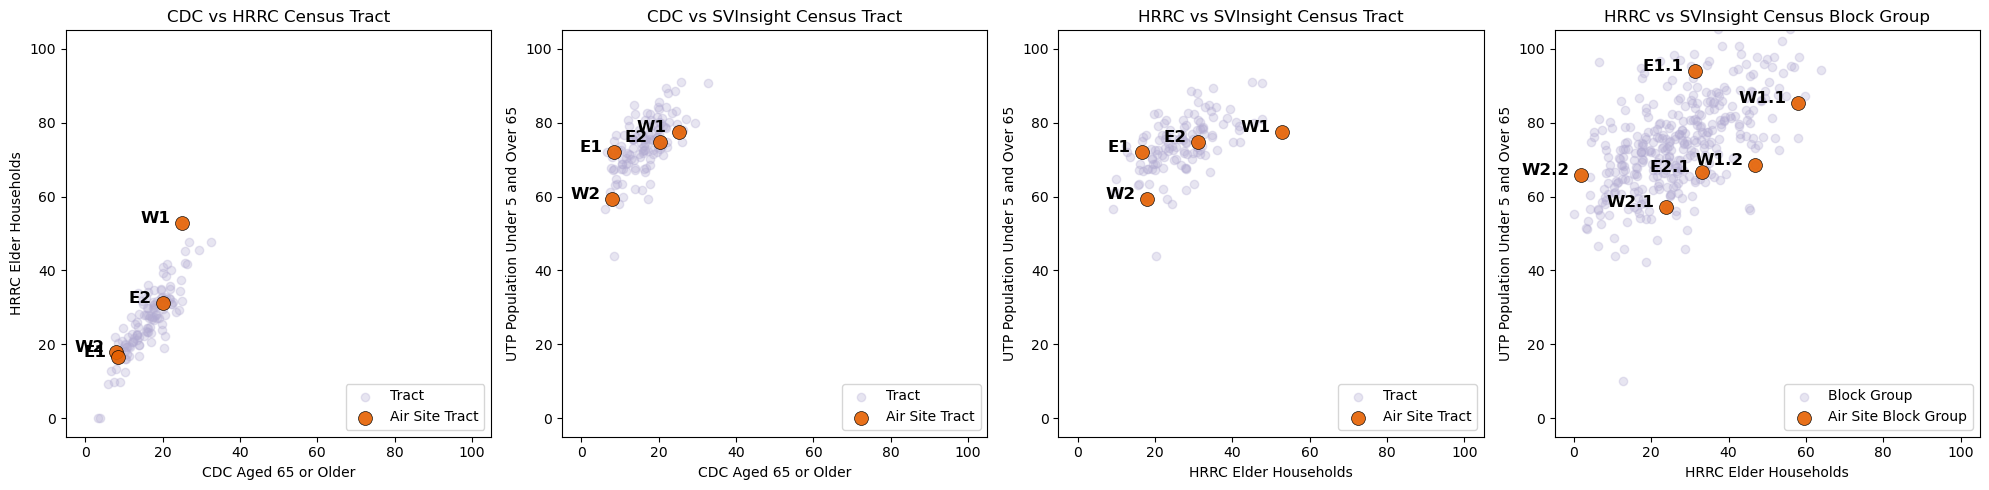

In [ ]:
svi_tract_gdf_setx, svi_tract_gdf_airsite = select_svi_vars(Tract_df, cat_vars_tract, airsite_var='airsite_tract')
svi_bg_gdf_setx, svi_bg_gdf_airsite = select_svi_vars(BG_df, cat_vars_bg, airsite_var='airsite_bg')
generate_plot(svi_tract_gdf_setx, 
              svi_tract_gdf_airsite, 
              svi_bg_gdf_setx, 
              svi_bg_gdf_airsite, 
              commonlabel = "age",
              cdc_varname = varnames['CDC'],
              hrrc_varname = varnames['HRRC'],
              SVInsight_varname = varnames['SVInsight'],
              label_cdc = labels['CDC'],
              label_hrrc = labels['HRRC'],
              label_SVInsight = labels['SVInsight'])

In [23]:
# Scatter plots for Age
common_category = 'Poverty'
condition1 = table2_df_v2['Common Category'] == common_category

labels = {}
varnames = {}
cat_vars_tract = []

for svi_option in ['CDC', 'HRRC', 'UTP']:
    varnames[svi_option] = table2_df_v2.loc[condition1, f'newvarname {svi_option}'].values[0]
    condition2 = table1_df[f'newvarname {svi_option}'] == varnames[svi_option]
    labels[svi_option] = svi_option + ' ' + table1_df.loc[condition2, 'Common Category'].values[0]
    print(labels[svi_option])

cat_vars_tract = [varnames['CDC'], varnames['HRRC'], varnames['UTP']]
cat_vars_bg = [varnames['HRRC'], varnames['UTP']]
print(common_category, cat_vars_tract)

CDC Poverty
HRRC Poverty
UTP Poverty
Poverty ['C202020010', 'H202020010', 'U202020010']


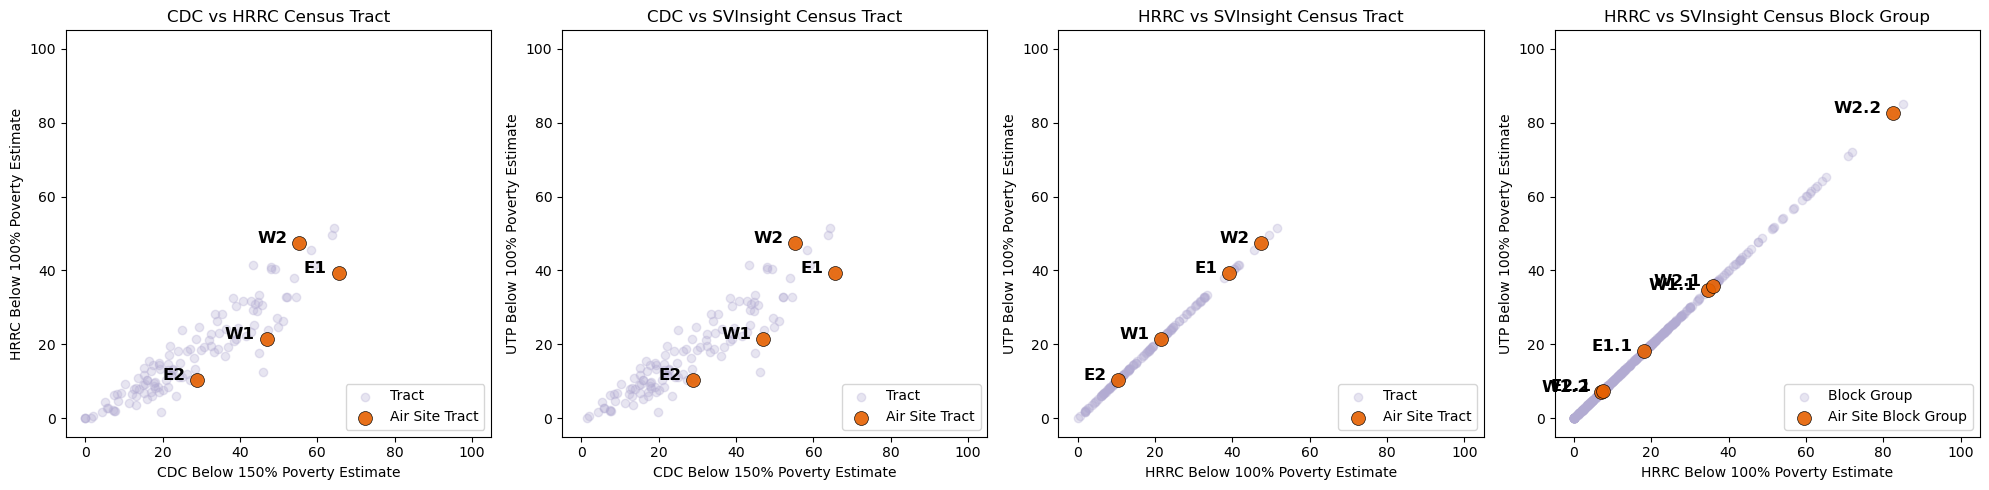

In [24]:
svi_tract_gdf_setx, svi_tract_gdf_airsite = select_svi_vars(Tract_df, cat_vars_tract, airsite_var='airsite_tract')
svi_bg_gdf_setx, svi_bg_gdf_airsite = select_svi_vars(BG_df, cat_vars_bg, airsite_var='airsite_bg')
generate_plot(svi_tract_gdf_setx, 
              svi_tract_gdf_airsite, 
              svi_bg_gdf_setx, 
              svi_bg_gdf_airsite, 
              commonlabel = "poverty",
              cdc_varname = varnames['CDC'],
              hrrc_varname = varnames['HRRC'],
              utp_varname = varnames['UTP'],
              label_cdc = 'CDC Below 150% Poverty Estimate',
              label_hrrc = 'HRRC Below 100% Poverty Estimate',
              label_utp = 'UTP Below 100% Poverty Estimate')

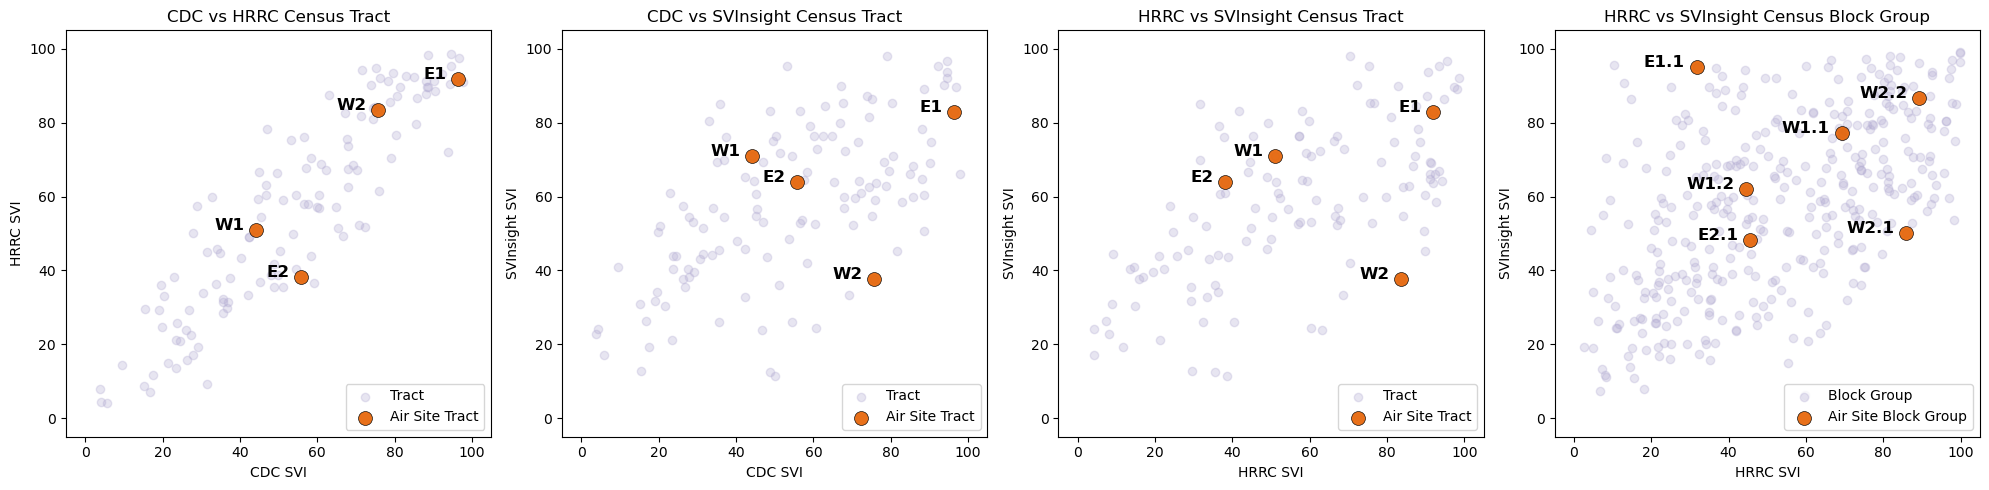

In [28]:
cat_vars_tract = ['C202090012', 'H202090012', 'U202090012']
cat_vars_bg = ['H202090012', 'U202090012']
def select_svi_vars_v2(df, cat_vars, airsite_var):
    # select southeast texas counties
    df_setx = df[df['SETX'] == 1].copy(deep=True)
    df_airsites = df_setx[df_setx[airsite_var] == 1].copy(deep=True)

    return df_setx, df_airsites


svi_tract_gdf_setx, svi_tract_gdf_airsite = select_svi_vars_v2(Tract_df, cat_vars_tract, airsite_var='airsite_tract')
svi_bg_gdf_setx, svi_bg_gdf_airsite = select_svi_vars_v2(BG_df, cat_vars_bg, airsite_var='airsite_bg')

generate_plot(svi_tract_gdf_setx, 
              svi_tract_gdf_airsite, 
              svi_bg_gdf_setx, 
              svi_bg_gdf_airsite, 
              commonlabel = "SVIoptions",
              cdc_varname = 'C202090012',
              hrrc_varname = 'H202090012',
              utp_varname = 'U202090012',
              label_cdc = 'CDC SVI',
              label_hrrc = 'HRRC SVI',
              label_utp = 'SVInsight SVI')